<a href="https://colab.research.google.com/github/kartikeyabekkari/HyperRealisticNisqSimulation/blob/main/Hyper_Realistic_NISQ_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup & Imports



In [ ]:
!pip install --upgrade --force-reinstall cirq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.7/733.7 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.5/176.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import warnings
warnings.filterwarnings("ignore")


try:
    import cirq
except ImportError:
    print("installing cirq...")
    !pip install cirq --quiet
    import cirq
    print("installed cirq.")


import matplotlib.pyplot as plt
import cirq_web
import numpy as np

print("Libraries Imported Successfully!")

Libraries Imported Successfully!




---


#Parameters





In [ ]:
import cirq
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
deg = np.radians

---

In [ ]:
#================ Parameters =================

number_of_qubits_in_the_circuit = 3
number_of_runs = 4096
base_noise = 0.018 # <---- In Decimal Representation of Percentage
high_noise = 0.027 # <---- In Decimal Representation of Percentage
distance_between_qubits = 2 # <---- In Micro Meters
frequency_overlap = 0 # <---- In Gigahertz

#=============== Build Circuit ===============
qubits = cirq.LineQubit.range(number_of_qubits_in_the_circuit)
base_circuit = cirq.Circuit([

#---------------------------------------------
 cirq.H(qubits[0]),
 cirq.CNOT(qubits[0], qubits[1]),
 cirq.CNOT(qubits[0], qubits[2]),
 cirq.measure(qubits, key='result')
#---------------- Edit Here ^ ----------------

])
#=================== Show ====================

print(f'Your Circuit:\n\n{base_circuit}\n')

Your Circuit:

0: ───H───@───@───M('result')───
          │   │   │
1: ───────X───┼───M─────────────
              │   │
2: ───────────X───M─────────────



#Functions

In [ ]:
def inject_errors(original_circuit):
      noisy_circuit = cirq.Circuit()
      for moment in original_circuit:
        # Add the original operations first
          noisy_circuit.append(moment)

        # Skip noise injection entirely if moment contains a measurement
          if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
              continue

          active_loud_qubits = set()

          for op in moment:
              is_loud_gate = isinstance(op.gate, (
                  cirq.XPowGate,
                  cirq.YPowGate,
                  cirq.ZPowGate,
                  cirq.HPowGate,
                  cirq.CXPowGate,
                  cirq.PhasedXPowGate
              ))

              if is_loud_gate:
                  active_loud_qubits.update(op.qubits)

          error_gates = []
          for q in original_circuit.all_qubits():
              # Sets error to
              error_rate = high_noise if q in active_loud_qubits else base_noise
              error_gates.append(cirq.bit_flip(p=error_rate)(q))

          # Add the error gates to the noisy circuit
          noisy_circuit.append(cirq.Moment(error_gates))

      return noisy_circuit
noisy_circuit = inject_errors(base_circuit)
noisy_circuit

0: ───H───BF(0.027)───@───BF(0.027)───@───BF(0.027)───M('result')───
                      │               │               │
1: ───────BF(0.018)───X───BF(0.027)───┼───BF(0.018)───M─────────────
                                      │               │
2: ───────BF(0.018)───────BF(0.018)───X───BF(0.027)───M─────────────

In [ ]:

def find_errors():
  simulator = cirq.Simulator()
  error_qubit_stream = []
  noisy_moments = list(inject_errors(base_circuit))
    # Store list of moments directly to check what gates are inside




    # Stochastic trajectory sampling replaces the original broken .sample() step here
  for current_moment in noisy_moments:
        is_error_moment = any(isinstance(op.gate, cirq.BitFlipChannel) for op in current_moment)
        if is_error_moment:
            flipped_qubits = []
            for op in current_moment:
                if isinstance(op.gate, cirq.BitFlipChannel):
                    p_val = op.gate.p
                    # FIX: Access the single qubit from the op.qubits tuple
                    q_idx = qubits.index(op.qubits[0])
                    if np.random.rand() < p_val:
                        flipped_qubits.append(q_idx)
            if flipped_qubits:
                error_qubit_stream.append(flipped_qubits)
            else:
                error_qubit_stream.append([])
        else:
            error_qubit_stream.append([])
  return error_qubit_stream, noisy_moments
find_errors()

([[], [], [], [], [], [], []],
 [cirq.Moment(
      cirq.H(cirq.LineQubit(0)),
  ),
  cirq.Moment(
      cirq.bit_flip(p=0.027).on(cirq.LineQubit(0)),
      cirq.bit_flip(p=0.018).on(cirq.LineQubit(1)),
      cirq.bit_flip(p=0.018).on(cirq.LineQubit(2)),
  ),
  cirq.Moment(
      cirq.CNOT(cirq.LineQubit(0), cirq.LineQubit(1)),
  ),
  cirq.Moment(
      cirq.bit_flip(p=0.027).on(cirq.LineQubit(0)),
      cirq.bit_flip(p=0.027).on(cirq.LineQubit(1)),
      cirq.bit_flip(p=0.018).on(cirq.LineQubit(2)),
  ),
  cirq.Moment(
      cirq.CNOT(cirq.LineQubit(0), cirq.LineQubit(2)),
  ),
  cirq.Moment(
      cirq.bit_flip(p=0.027).on(cirq.LineQubit(0)),
      cirq.bit_flip(p=0.018).on(cirq.LineQubit(1)),
      cirq.bit_flip(p=0.027).on(cirq.LineQubit(2)),
  ),
  cirq.Moment(
      cirq.measure(cirq.LineQubit(0), cirq.LineQubit(1), cirq.LineQubit(2), key=cirq.MeasurementKey(name='result')),
  )])

In [ ]:
def create_final_circuit(original_circuit, qubit_stream, noisy_moments_list):
        building_circuit = cirq.Circuit()
        all_qubits = sorted(list(original_circuit.all_qubits()))
        stream_idx = 0
        for base_step_idx, moment in enumerate(original_circuit):
            building_circuit.append(moment)
            if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
                continue
            detected_flips = 0
            while stream_idx < len(noisy_moments_list) and stream_idx < len(qubit_stream):
                moment_to_check = noisy_moments_list[stream_idx]
                is_error = any(isinstance(op.gate, cirq.BitFlipChannel) for op in moment_to_check)
                if is_error:
                    detected_flips = qubit_stream[stream_idx]
                    stream_idx += 1
                    break
                stream_idx += 1
            crosstalk_noise_gates = []
            for q_idx, qubit in enumerate(all_qubits):
                if isinstance(detected_flips, list) and q_idx in detected_flips:
                    noise_chance = 1.0
                elif isinstance(detected_flips, list) and len(detected_flips) > 0:
                    neighbor_distances = [abs(q_idx - flipped_idx) for flipped_idx in detected_flips]
                    shortest_neighbor_distance = min(neighbor_distances)
                    noise_chance = (
                        1.0 / ((shortest_neighbor_distance*distance_between_qubits)**4)
                    )
                else:
                    noise_chance = 0.0
                crosstalk_noise_gates.append(cirq.bit_flip(p=noise_chance)(qubit))
            building_circuit.append(cirq.Moment(crosstalk_noise_gates))
        return building_circuit

In [ ]:
total_counts = Counter()
def simulate(type_of_noise):
    sim = cirq.Simulator(noise=type_of_noise)
    result = sim.run(final_circuit)
    run_count = result.histogram(key='result')
    total_counts.update(run_count)


In [ ]:
def Graph():
  print("\n--- SIMULATION RESULTS ---\n")

  total_possible_states = 2**number_of_qubits_in_the_circuit
  labels = []
  values = []
  for outcome in range(total_possible_states):
      binary_string = format(outcome, f"0{number_of_qubits_in_the_circuit}b")
      labels.append(binary_string)
      actual_count = total_counts.get(outcome, 0)
      values.append(actual_count)
      print(f"State |{binary_string}⟩: Happened {actual_count} times total = {(float(actual_count/number_of_runs)*100):.2f}%")

  # Final graph
  plt.figure(figsize=(1+2*number_of_qubits_in_the_circuit, 6))
  plt.bar(labels, values, color="lightblue", edgecolor="lightblue")
  plt.title(f"Combined Total For {number_of_runs} Procedural Runs")
  plt.xlabel("Quantum States")
  plt.ylabel("Total Count")
  plt.xticks(rotation=315, fontsize=8)
  plt.grid(axis="y", linestyle="--", alpha=0.85)
  plt.tight_layout()

  plt.show()


---
#Run The Circuit
---

Circuit:
0: ───H───@───@───M('result')───
          │   │   │
1: ───────X───┼───M─────────────
              │   │
2: ───────────X───M─────────────


--- SIMULATION RESULTS ---

State |000⟩: Happened 440 times total = 44.00%
State |001⟩: Happened 41 times total = 4.10%
State |010⟩: Happened 46 times total = 4.60%
State |011⟩: Happened 31 times total = 3.10%
State |100⟩: Happened 25 times total = 2.50%
State |101⟩: Happened 35 times total = 3.50%
State |110⟩: Happened 34 times total = 3.40%
State |111⟩: Happened 348 times total = 34.80%


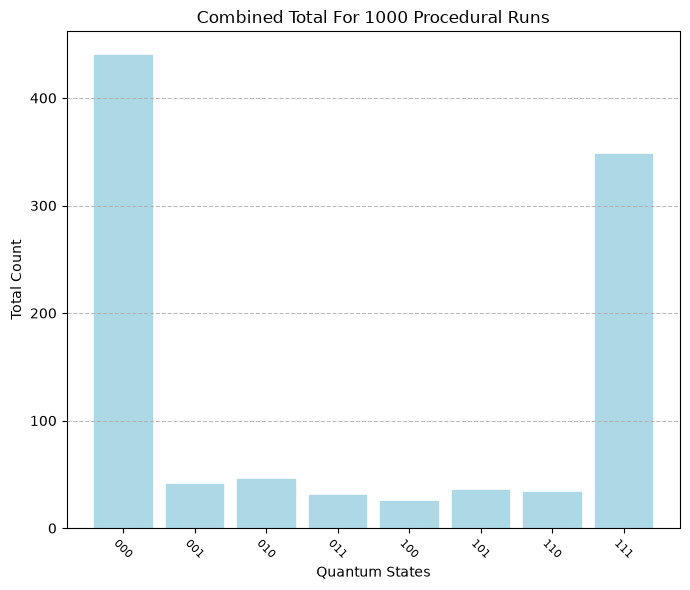

In [ ]:
total_counts.clear() #--- Reset the count
number_of_runs = 1000

for num in range(number_of_runs): #--- Run the following once per shot
  noisy_circuit = inject_errors(base_circuit) #--- Create the noisy_circuit
  final_circuit = create_final_circuit(base_circuit, find_errors()[0], find_errors()[1]) #--- Create a final circuit that models crosstalk | find_errors[0] creates list of flipped qubits, find_errors[1] creates list of noisy moments(slices)
  simulate(cirq.amplitude_damp(0.01)) #--- Simulate the final circuit | Set the type of noise inside the parenthesis
print(f'Circuit:\n{base_circuit}\n')
Graph() #--- Graph the results | Needs to be outside the run loop |

In [ ]:
import math
number_choices = 16
correct_choice = 3

"Get qubits to use in the circuit for Grover's algorithm."
nqubits = 4

def generate_binary_strings(number_choices):
    n = int(math.log(number_choices,2))
    binary_strings = []
    for i in range(2**n):
        binary_string = bin(i)[2:].zfill(n)
        binary_strings.append(binary_string)
    return binary_strings

ls = generate_binary_strings(number_choices)
print(ls)

def make_oracle(qubits, ancilla, marked_bitstring):
    """Implements the function {f(x) = 1 if x == x', f(x) = 0 if x != x'}."""
    # For x' = (1, 1), the oracle is just a Toffoli gate.
    # For a general x', we negate the zero bits and implement a Toffoli.

    # Negate zero bits, if necessary.
    for (q, bit) in zip(qubits, marked_bitstring):
        if not bit:
            yield (cirq.X(q))
    # Do the Toffoli. change this to MCX for a generalized oracle
    #yield (cirq.TOFFOLI(qubits[0], qubits[1], ancilla))
    # controls = len(qubits) -1
    controls = len(qubits)
    mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
    yield (mcx_gate(*qubits, ancilla))

    # Negate zero bits, if necessary.
    for (q, bit) in zip(qubits, marked_bitstring):
        if not bit:
            yield (cirq.X(q))

def grover_iteration(qubits, ancilla, marked_bitstring, reps=1):
    """Performs one round of the Grover iteration."""
    circuit = cirq.Circuit()

    # Create an equal superposition over input qubits.
    circuit.append(cirq.H.on_each(*qubits))

    # Put the output qubit in the |-⟩ state.
    circuit.append([cirq.X(ancilla), cirq.H(ancilla)])
    for r in range(reps):
        # Query the oracle.
        # circuit.append(oracle)
        for (q, bit) in zip(qubits, marked_bitstring):
            if not bit:
                circuit.append([cirq.X(q)])
        # Do the Toffoli. change this to MCX for a generalized oracle
        #yield (cirq.TOFFOLI(qubits[0], qubits[1], ancilla))
        # controls = len(qubits) -1
        controls = len(qubits)
        mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
        circuit.append([mcx_gate(*qubits, ancilla)])

        # Negate zero bits, if necessary.
        for (q, bit) in zip(qubits, marked_bitstring):
            if not bit:
                circuit.append([cirq.X(q)])

        # Construct Grover operator.
        circuit.append(cirq.H.on_each(*qubits))
        circuit.append(cirq.X.on_each(*qubits))

        # circuit.append(cirq.H.on(qubits[-1]))
        controls = len(qubits)
        mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
        mcx_op = mcx_gate(*qubits, ancilla)
        circuit.append(mcx_op)
        # circuit.append(cirq.H.on(qubits[-1]))

        circuit.append(cirq.X.on_each(*qubits))
        circuit.append(cirq.H.on_each(*qubits))

    # Measure the input register.
    circuit.append(cirq.measure(*qubits, key="result"))

    return circuit

# Get qubit registers.
qubits = cirq.LineQubit.range(nqubits)
ancilla = cirq.LineQubit(nqubits)

def get_marked_bitstring(correct_choice, nqubits):
    binary_representation = list(bin(correct_choice)[2:])
    marked_bitstring = [eval(i) for i in binary_representation]
    desired_length = nqubits
    marked_bitstring = [0] * (desired_length - len(marked_bitstring)) + marked_bitstring
    return marked_bitstring

marked_bitstring = get_marked_bitstring(correct_choice, nqubits)

"""Create the circuit for Grover's algorithm."""
# Make oracle (black box)
oracle = make_oracle(qubits, ancilla, marked_bitstring)

# Embed the oracle into a quantum circuit implementing Grover's algorithm.
base_circuit = grover_iteration(qubits, ancilla, marked_bitstring)

"""Simulate the circuit for Grover's algorithm and check the output."""
# Helper function.
def bitstring(bits):
    return "".join(str(int(b)) for b in bits)

def binary_labels(num_qubits):
    return [bin(x)[2:].zfill(num_qubits) for x in range(2 ** num_qubits)]

# Sample from the circuit a couple times.
simulator = cirq.Simulator()
result = simulator.run(base_circuit, repetitions = 1024)

# Look at the sampled bitstrings.
frequencies = result.histogram(key="result", fold_func=bitstring)
print('Sampled results:\n{}'.format(frequencies))

# Check if we actually found the secret value.
most_common_bitstring = frequencies.most_common(1)[0][0]
print("\nMost common bitstring: {}".format(most_common_bitstring))
print("Found a match? {}".format(most_common_bitstring == bitstring(marked_bitstring)))
print(base_circuit)

['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']
Sampled results:
Counter({'0011': 486, '1001': 44, '0111': 42, '1000': 42, '1011': 42, '1110': 38, '0000': 36, '1100': 35, '0101': 34, '1010': 34, '0110': 33, '0010': 33, '0001': 33, '1101': 33, '0100': 30, '1111': 29})

Most common bitstring: 0011
Found a match? True
0: ───H───X───@───X───H───X───@───X───H───M('result')───
              │               │           │
1: ───H───X───@───X───H───X───@───X───H───M─────────────
              │               │           │
2: ───H───────@───H───X───────@───X───H───M─────────────
              │               │           │
3: ───H───────@───H───X───────@───X───H───M─────────────
              │               │
4: ───X───H───X───────────────X─────────────────────────


Circuit:
0: ───H───X───@───X───H───X───@───X───H───M('result')───
              │               │           │
1: ───H───X───@───X───H───X───@───X───H───M─────────────
              │               │           │
2: ───H───────@───H───X───────@───X───H───M─────────────
              │               │           │
3: ───H───────@───H───X───────@───X───H───M─────────────
              │               │
4: ───X───H───X───────────────X─────────────────────────


--- SIMULATION RESULTS ---

State |0000⟩: Happened 0 times total = 0.00%
State |0001⟩: Happened 0 times total = 0.00%
State |0010⟩: Happened 0 times total = 0.00%
State |0011⟩: Happened 3 times total = 30.00%
State |0100⟩: Happened 0 times total = 0.00%
State |0101⟩: Happened 0 times total = 0.00%
State |0110⟩: Happened 0 times total = 0.00%
State |0111⟩: Happened 2 times total = 20.00%
State |1000⟩: Happened 1 times total = 10.00%
State |1001⟩: Happened 0 times total = 0.00%
State |1010⟩: Happened 0 times total = 0.00%
State |1011⟩: 

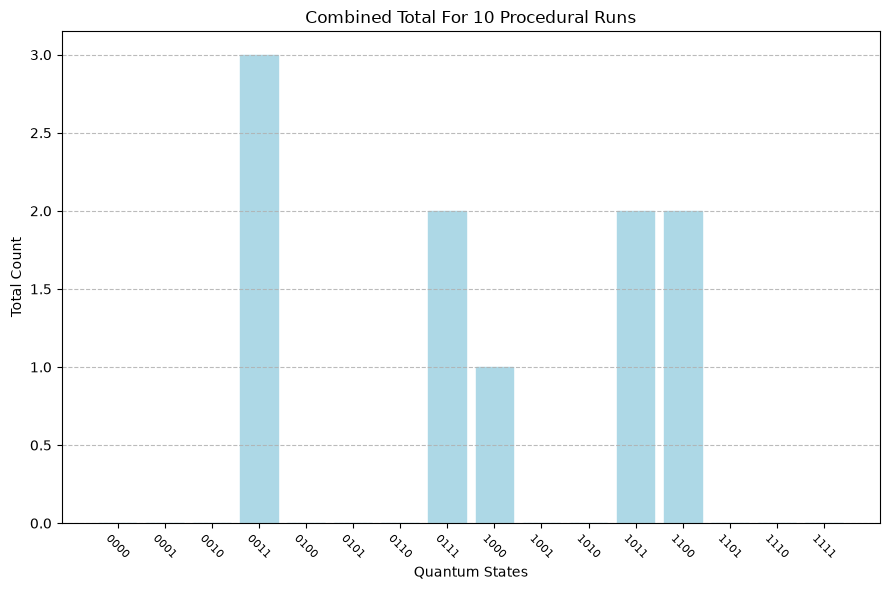

In [ ]:
number_of_qubits_in_the_circuit = nqubits
total_counts.clear() #--- Reset the count
number_of_runs = 10

# Update the global 'qubits' variable to include all qubits from the current base_circuit (Grover's),
# ensuring that find_errors() can correctly map all qubits to an index.
global qubits
qubits = sorted(list(base_circuit.all_qubits()))

for num in range(number_of_runs): #--- Run the following once per shot
  noisy_circuit = inject_errors(base_circuit) #--- Create the noisy_circuit
  final_circuit = create_final_circuit(base_circuit, find_errors()[0], find_errors()[1]) #--- Create a final circuit that models crosstalk | find_errors[0] creates list of flipped qubits, find_errors[1] creates list of noisy moments(slices)
  simulate(cirq.amplitude_damp(0.01)) #--- Simulate the final circuit | Set the type of noise inside the parenthesis
print(f'Circuit:\n{base_circuit}\n')
Graph() #--- Graph the results | Needs to be outside the run loop |